## Semantic Clustering Baseline: K-means (Word2Vec + GloVe )


In [ ]:
%pip install -q pandas pyarrow numpy scikit-learn gensim rapidfuzz matplotlib seaborn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 101.6 MB/s eta 0:00:00


In [ ]:
from __future__ import annotations

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

from gensim.models import Word2Vec
import gensim.downloader as api
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [ ]:
# Config (Colab + local)
IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)

PROJECT_CANDIDATES = [
    Path('/content/drive/MyDrive/Диплом'),
    Path('/content/drive/MyDrive/Гузель/магистратура/Диплом'),
    Path('/content/drive/MyDrive/YandexDisk/Гузель/магистратура/Диплом'),
    Path(r'D:\YandexDisk\Гузель\магистратура\Диплом'),
    Path.cwd(),
]

PROJECT_DIR = next((p for p in PROJECT_CANDIDATES if p.exists()), Path.cwd())
DATASET_NAME = 'dataset_clean_unique_keywords_keep_best_row.parquet'

# Ищем датасет сначала в PROJECT_DIR, затем в типичных подпапках
search_roots = [PROJECT_DIR, PROJECT_DIR / 'processed_parquet']
if IN_COLAB:
    search_roots.extend([
        Path('/content/drive/MyDrive'),
        Path('/content/drive/MyDrive/Диплом'),
        Path('/content/drive/MyDrive/Гузель/магистратура/Диплом'),
    ])

DATASET_PATH = None
for root in search_roots:
    candidate = root / DATASET_NAME
    if candidate.exists():
        DATASET_PATH = candidate
        break

if DATASET_PATH is None:
    for root in search_roots:
        if root.exists():
            found = list(root.rglob(DATASET_NAME))
            if found:
                DATASET_PATH = found[0]
                break

if DATASET_PATH is None:
    DATASET_PATH = PROJECT_DIR / DATASET_NAME

KEYWORD_COL = 'Keyword'
MAX_WORDS = None  # None = использовать все уникальные keywords
MIN_TOKEN_LEN = 2
DATA_SCOPE_TAG = 'all' if MAX_WORDS is None else f'top{MAX_WORDS}'

W2V_VECTOR_SIZE = 100
W2V_WINDOW = 5
W2V_MIN_COUNT = 1
W2V_EPOCHS = 20

# Режим запуска: 'glove_only' | 'word2vec_only' | 'both'
RUN_MODE = 'word2vec_only'
if RUN_MODE == 'glove_only':
    RUN_WORD2VEC = False
    RUN_GLOVE = True
elif RUN_MODE == 'word2vec_only':
    RUN_WORD2VEC = True
    RUN_GLOVE = False
else:
    RUN_WORD2VEC = True
    RUN_GLOVE = True

# Профиль для полного датасета в Colab
FAST_FULL_RUN = True
if FAST_FULL_RUN:
    K_VALUES = (5, 8, 10)
    MAX_ITER = 60
    INTRA_MAX_POINTS_PER_CLUSTER = 200
    INTRA_MAX_PAIR_SAMPLES = 1000
else:
    K_VALUES = (5, 8, 10, 12)
    MAX_ITER = 100
    INTRA_MAX_POINTS_PER_CLUSTER = 300
    INTRA_MAX_PAIR_SAMPLES = 2000

RANDOM_STATE = 42
MINI_BATCH_SIZE = 4096
METRIC_SAMPLE_SIZE = 30000

# Чекпоинты: периодически сохраняем промежуточные результаты
CHECKPOINT_DIR = PROJECT_DIR / 'semantic_checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
ENABLE_CHECKPOINTS = True
REUSE_EMBEDDINGS_CHECKPOINT = True

print('IN_COLAB:', IN_COLAB)
print('PROJECT_DIR:', PROJECT_DIR)
print('DATASET_PATH:', DATASET_PATH)
print('DATASET_PATH exists:', DATASET_PATH.exists())
print('CHECKPOINT_DIR:', CHECKPOINT_DIR)
print('REUSE_EMBEDDINGS_CHECKPOINT:', REUSE_EMBEDDINGS_CHECKPOINT)
print('FAST_FULL_RUN:', FAST_FULL_RUN)
print('RUN_MODE:', RUN_MODE)
print('RUN_WORD2VEC:', RUN_WORD2VEC)
print('RUN_GLOVE:', RUN_GLOVE)
print('K_VALUES:', K_VALUES)
print('MAX_ITER:', MAX_ITER)
print('METRIC_SAMPLE_SIZE:', METRIC_SAMPLE_SIZE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IN_COLAB: True
PROJECT_DIR: /content/drive/MyDrive/Диплом
DATASET_PATH: /content/drive/MyDrive/Диплом/dataset_clean_unique_keywords_keep_best_row.parquet
DATASET_PATH exists: True
CHECKPOINT_DIR: /content/drive/MyDrive/Диплом/semantic_checkpoints
REUSE_EMBEDDINGS_CHECKPOINT: True
FAST_FULL_RUN: True
RUN_MODE: word2vec_only
RUN_WORD2VEC: True
RUN_GLOVE: False
K_VALUES: (5, 8, 10)
MAX_ITER: 60
METRIC_SAMPLE_SIZE: 30000


In [ ]:
def normalize_text(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r'[^\w\s-]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text


def tokenize_keyword(text: str) -> list[str]:
    t = normalize_text(text)
    toks = [w for w in t.split() if len(w) >= MIN_TOKEN_LEN]
    return toks


def phrase_vector_from_model(tokens: list[str], model, vector_size: int) -> np.ndarray:
    vecs = []
    for tok in tokens:
        if tok in model:
            vecs.append(model[tok])
    if not vecs:
        return np.zeros(vector_size, dtype=np.float32)
    return np.mean(np.array(vecs, dtype=np.float32), axis=0)


def mean_intra_cosine_similarity(
    X: np.ndarray,
    labels: np.ndarray,
    max_points_per_cluster: int = INTRA_MAX_POINTS_PER_CLUSTER,
    max_pair_samples: int = INTRA_MAX_PAIR_SAMPLES,
    random_state: int = RANDOM_STATE,
) -> float:
    rng = np.random.default_rng(random_state)
    sims: list[float] = []

    # Нормируем векторы для cosine через скалярное произведение
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    Xn = X / np.maximum(norms, 1e-12)

    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        if idx.size < 2:
            continue

        if idx.size > max_points_per_cluster:
            idx = rng.choice(idx, size=max_points_per_cluster, replace=False)

        m = idx.size
        all_pairs = m * (m - 1) // 2
        if all_pairs <= max_pair_samples:
            local = Xn[idx]
            sim_matrix = local @ local.T
            tri = np.triu_indices(m, k=1)
            pair_sims = sim_matrix[tri]
        else:
            i1 = rng.integers(0, m, size=max_pair_samples)
            i2 = rng.integers(0, m, size=max_pair_samples)
            neq = i1 != i2
            if not np.any(neq):
                continue
            i1 = i1[neq]
            i2 = i2[neq]
            pair_sims = np.sum(Xn[idx[i1]] * Xn[idx[i2]], axis=1)

        if pair_sims.size > 0:
            sims.append(float(np.mean(pair_sims)))

    if not sims:
        return float('nan')
    return float(np.mean(sims))


def evaluate_clustering(X: np.ndarray, labels: np.ndarray) -> dict[str, float]:
    # Метрики требуют >=2 кластеров
    if len(np.unique(labels)) < 2:
        return {
            'silhouette': np.nan,
            'calinski_harabasz': np.nan,
            'davies_bouldin': np.nan,
            'intra_cosine': np.nan,
        }

    # На полном датасете (миллионы строк) silhouette/CH/DB слишком дорогие,
    # поэтому считаем на репрезентативном сэмпле.
    X_eval = X
    labels_eval = labels
    if X.shape[0] > METRIC_SAMPLE_SIZE:
        rng = np.random.default_rng(RANDOM_STATE)
        idx = rng.choice(X.shape[0], size=METRIC_SAMPLE_SIZE, replace=False)
        X_eval = X[idx]
        labels_eval = labels[idx]

    # Для ускорения baseline отключаем дорогой расчет intra_cosine.
    return {
        'silhouette': float(silhouette_score(X_eval, labels_eval, metric='euclidean')),
        'calinski_harabasz': float(calinski_harabasz_score(X_eval, labels_eval)),
        'davies_bouldin': float(davies_bouldin_score(X_eval, labels_eval)),
        'intra_cosine': np.nan,
    }


def save_kmeans_checkpoint(
    model_name: str,
    k: int,
    labels: np.ndarray,
    metrics_df: pd.DataFrame,
    keyword_series: pd.Series,
) -> None:
    if not ENABLE_CHECKPOINTS:
        return

    safe_model = re.sub(r'[^a-zA-Z0-9_-]+', '_', model_name)
    labels_path = CHECKPOINT_DIR / f'checkpoint_{safe_model}_k{k}_labels.parquet'
    metrics_path = CHECKPOINT_DIR / f'checkpoint_{safe_model}_metrics.parquet'

    checkpoint_labels = pd.DataFrame({
        KEYWORD_COL: keyword_series.values,
        f'cluster_{safe_model}': labels,
    })

    checkpoint_labels.to_parquet(labels_path, index=False)
    metrics_df.to_parquet(metrics_path, index=False)
    print(f'[checkpoint] saved {labels_path.name} and {metrics_path.name}')

In [ ]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(f'Не найден датасет: {DATASET_PATH}')

base_df = pd.read_parquet(DATASET_PATH, columns=[KEYWORD_COL])
base_df = base_df.dropna(subset=[KEYWORD_COL]).copy()
base_df[KEYWORD_COL] = base_df[KEYWORD_COL].astype(str)
base_df = base_df.drop_duplicates(subset=[KEYWORD_COL])

if MAX_WORDS is not None:
    base_df = base_df.head(MAX_WORDS).copy()

base_df['tokens'] = base_df[KEYWORD_COL].map(tokenize_keyword)
base_df = base_df[base_df['tokens'].map(len) > 0].reset_index(drop=True)

print('keywords for baseline:', len(base_df))
base_df.head(3)

keywords for baseline: 13224196


,Keyword,tokens
0,neuro talk,"[neuro, talk]"
1,berafa,[berafa]
2,micro fulfillment,"[micro, fulfillment]"


In [ ]:
sentences = base_df['tokens'].tolist()

X_w2v = None
W2V_EMB_PATH = CHECKPOINT_DIR / f'embeddings_word2vec_{DATA_SCOPE_TAG}.npy'

if RUN_WORD2VEC:
    if REUSE_EMBEDDINGS_CHECKPOINT and W2V_EMB_PATH.exists():
        X_w2v = np.load(W2V_EMB_PATH)
        print('Loaded Word2Vec embeddings from checkpoint:', W2V_EMB_PATH)
    else:
        w2v = Word2Vec(
            sentences=sentences,
            vector_size=W2V_VECTOR_SIZE,
            window=W2V_WINDOW,
            min_count=W2V_MIN_COUNT,
            workers=4,
            sg=1,
            seed=RANDOM_STATE,
            epochs=W2V_EPOCHS,
        )

        X_w2v = np.vstack([
            phrase_vector_from_model(toks, w2v.wv, W2V_VECTOR_SIZE)
            for toks in tqdm(sentences, desc='Word2Vec phrase vectors', unit='phrase')
        ])

        if ENABLE_CHECKPOINTS:
            np.save(W2V_EMB_PATH, X_w2v)
            print('Saved Word2Vec embeddings checkpoint:', W2V_EMB_PATH)

print('Word2Vec matrix:', None if X_w2v is None else X_w2v.shape)

Word2Vec phrase vectors:   0%|          | 0/13224196 [00:00<?, ?phrase/s]

Saved Word2Vec embeddings checkpoint: /content/drive/MyDrive/Диплом/semantic_checkpoints/embeddings_word2vec_all.npy
Word2Vec matrix: (13224196, 100)


In [ ]:
glove_name = 'glove-wiki-gigaword-50'
X_glove = None
GLOVE_EMB_PATH = CHECKPOINT_DIR / f'embeddings_glove_{DATA_SCOPE_TAG}.npy'

if RUN_GLOVE:
    if REUSE_EMBEDDINGS_CHECKPOINT and GLOVE_EMB_PATH.exists():
        X_glove = np.load(GLOVE_EMB_PATH)
        print('Loaded GloVe embeddings from checkpoint:', GLOVE_EMB_PATH)
    else:
        glove_model = None
        try:
            glove_model = api.load(glove_name)
            print('Loaded:', glove_name)
        except Exception as exc:
            print('GloVe не загружен (offline/ограничения окружения):', exc)

        if glove_model is not None:
            X_glove = np.vstack([
                phrase_vector_from_model(toks, glove_model, glove_model.vector_size)
                for toks in tqdm(sentences, desc='GloVe phrase vectors', unit='phrase')
            ])

            if ENABLE_CHECKPOINTS:
                np.save(GLOVE_EMB_PATH, X_glove)
                print('Saved GloVe embeddings checkpoint:', GLOVE_EMB_PATH)

print('GloVe matrix:', None if X_glove is None else X_glove.shape)

[==================================================] 100.0% 66.0/66.0MB downloaded
Loaded: glove-wiki-gigaword-50


GloVe phrase vectors:   0%|          | 0/13224196 [00:00<?, ?phrase/s]

Saved GloVe embeddings checkpoint: /content/drive/MyDrive/Диплом/semantic_checkpoints/embeddings_glove_all.npy
GloVe matrix: (13224196, 50)


In [ ]:
def run_kmeans_grid(
    X: np.ndarray,
    model_name: str,
    keyword_series: pd.Series,
    k_values: tuple[int, ...] = K_VALUES,
):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    rows = []
    labels_by_k: dict[int, np.ndarray] = {}

    for k in tqdm(k_values, desc=f'KMeans grid ({model_name})', unit='k'):
        print(f'Running {model_name} for k={k} ...')
        km = MiniBatchKMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            batch_size=MINI_BATCH_SIZE,
            max_iter=MAX_ITER,
            n_init=10,
        )
        labels = km.fit_predict(Xs)
        labels_by_k[k] = labels
        print(f'[{model_name}] k={k}: fit complete, computing metrics on sample ...')

        scores = evaluate_clustering(Xs, labels)
        rows.append({
            'embedding': model_name,
            'k': k,
            'silhouette': scores['silhouette'],
            'calinski_harabasz': scores['calinski_harabasz'],
            'davies_bouldin': scores['davies_bouldin'],
            'intra_cosine': scores['intra_cosine'],
        })

        metrics_df = pd.DataFrame(rows)
        metrics_df['r_sil'] = metrics_df['silhouette'].rank(ascending=False, method='min')
        metrics_df['r_ch'] = metrics_df['calinski_harabasz'].rank(ascending=False, method='min')
        metrics_df['r_db'] = metrics_df['davies_bouldin'].rank(ascending=True, method='min')
        metrics_df['rank_sum'] = metrics_df[['r_sil', 'r_ch', 'r_db']].sum(axis=1)

        save_kmeans_checkpoint(
            model_name=model_name,
            k=k,
            labels=labels,
            metrics_df=metrics_df.sort_values('rank_sum'),
            keyword_series=keyword_series,
        )

    metrics_df = pd.DataFrame(rows)

    # Ранжирование как в baseline: silhouette/CH больше лучше, DB меньше лучше
    metrics_df['r_sil'] = metrics_df['silhouette'].rank(ascending=False, method='min')
    metrics_df['r_ch'] = metrics_df['calinski_harabasz'].rank(ascending=False, method='min')
    metrics_df['r_db'] = metrics_df['davies_bouldin'].rank(ascending=True, method='min')
    metrics_df['rank_sum'] = metrics_df[['r_sil', 'r_ch', 'r_db']].sum(axis=1)

    best_row = metrics_df.sort_values(['rank_sum', 'silhouette', 'intra_cosine'], ascending=[True, False, False]).iloc[0]
    best_k = int(best_row['k'])

    return metrics_df.sort_values('rank_sum'), best_k, labels_by_k[best_k], Xs

In [ ]:
res_w2v = None
best_k_w2v = None
labels_w2v = None
Xs_w2v = None

res_glove = None
best_k_glove = None
labels_glove = None
Xs_glove = None

if X_w2v is not None:
    res_w2v, best_k_w2v, labels_w2v, Xs_w2v = run_kmeans_grid(
        X_w2v,
        'word2vec',
        keyword_series=base_df[KEYWORD_COL],
    )
    print('Word2Vec best k =', best_k_w2v)
    display(res_w2v)
else:
    print('Word2Vec branch skipped.')

if X_glove is not None:
    res_glove, best_k_glove, labels_glove, Xs_glove = run_kmeans_grid(
        X_glove,
        'glove',
        keyword_series=base_df[KEYWORD_COL],
    )
    print('GloVe best k =', best_k_glove)
    display(res_glove)
else:
    print('GloVe branch skipped or embeddings not available.')

metrics_parts = [x for x in [res_w2v, res_glove] if x is not None]
results_df = pd.concat(metrics_parts, ignore_index=True) if metrics_parts else pd.DataFrame()
results_df

KMeans grid (word2vec):   0%|          | 0/3 [00:00<?, ?k/s]

Running word2vec for k=5 ...
[word2vec] k=5: fit complete, computing metrics on sample ...
[checkpoint] saved checkpoint_word2vec_k5_labels.parquet and checkpoint_word2vec_metrics.parquet
Running word2vec for k=8 ...
[word2vec] k=8: fit complete, computing metrics on sample ...
[checkpoint] saved checkpoint_word2vec_k8_labels.parquet and checkpoint_word2vec_metrics.parquet
Running word2vec for k=10 ...
[word2vec] k=10: fit complete, computing metrics on sample ...
[checkpoint] saved checkpoint_word2vec_k10_labels.parquet and checkpoint_word2vec_metrics.parquet
Word2Vec best k = 5


,embedding,k,silhouette,calinski_harabasz,davies_bouldin,intra_cosine,r_sil,r_ch,r_db,rank_sum
0,word2vec,5,0.552406,9646.059570,3.405518,NaN,1.0,1.0,2.0,4.0
1,word2vec,8,0.547103,5898.300293,3.635487,NaN,2.0,2.0,3.0,7.0
2,word2vec,10,0.472107,4775.901367,3.199245,NaN,3.0,3.0,1.0,7.0


KMeans grid (glove):   0%|          | 0/3 [00:00<?, ?k/s]

Running glove for k=5 ...
[glove] k=5: fit complete, computing metrics on sample ...
[checkpoint] saved checkpoint_glove_k5_labels.parquet and checkpoint_glove_metrics.parquet
Running glove for k=8 ...
[glove] k=8: fit complete, computing metrics on sample ...
[checkpoint] saved checkpoint_glove_k8_labels.parquet and checkpoint_glove_metrics.parquet
Running glove for k=10 ...
[glove] k=10: fit complete, computing metrics on sample ...
[checkpoint] saved checkpoint_glove_k10_labels.parquet and checkpoint_glove_metrics.parquet
GloVe best k = 8


,embedding,k,silhouette,calinski_harabasz,davies_bouldin,intra_cosine,r_sil,r_ch,r_db,rank_sum
1,glove,8,0.435427,943.236328,3.383472,NaN,2.0,2.0,1.0,5.0
0,glove,5,0.423637,1189.964600,3.413290,NaN,3.0,1.0,2.0,6.0
2,glove,10,0.441205,788.583435,3.547698,NaN,1.0,3.0,3.0,7.0


,embedding,k,silhouette,calinski_harabasz,davies_bouldin,intra_cosine,r_sil,r_ch,r_db,rank_sum
0,word2vec,5,0.552406,9646.059570,3.405518,NaN,1.0,1.0,2.0,4.0
1,word2vec,8,0.547103,5898.300293,3.635487,NaN,2.0,2.0,3.0,7.0
2,word2vec,10,0.472107,4775.901367,3.199245,NaN,3.0,3.0,1.0,7.0
3,glove,8,0.435427,943.236328,3.383472,NaN,2.0,2.0,1.0,5.0
4,glove,5,0.423637,1189.964600,3.413290,NaN,3.0,1.0,2.0,6.0
5,glove,10,0.441205,788.583435,3.547698,NaN,1.0,3.0,3.0,7.0


In [ ]:
# Интерпретация Word2Vec/GloVe кластеров
out_w2v = None
if labels_w2v is not None:
    out_w2v = base_df[[KEYWORD_COL]].copy()
    out_w2v['cluster_word2vec'] = labels_w2v

    print(f'Размеры кластеров (Word2Vec, best k={best_k_w2v}):')
    display(out_w2v['cluster_word2vec'].value_counts().sort_index())

    for c in sorted(out_w2v['cluster_word2vec'].unique())[:5]:
        sample = out_w2v.loc[out_w2v['cluster_word2vec'] == c, KEYWORD_COL].head(15).tolist()
        print(f'\nWord2Vec Cluster {c}:')
        print(', '.join(sample))

out_glove = None
if labels_glove is not None:
    out_glove = base_df[[KEYWORD_COL]].copy()
    out_glove['cluster_glove'] = labels_glove
    print(f'\nРазмеры кластеров (GloVe, best k={best_k_glove}):')
    display(out_glove['cluster_glove'].value_counts().sort_index())

    for c in sorted(out_glove['cluster_glove'].unique())[:5]:
        sample = out_glove.loc[out_glove['cluster_glove'] == c, KEYWORD_COL].head(15).tolist()
        print(f'\nGloVe Cluster {c}:')
        print(', '.join(sample))

Размеры кластеров (Word2Vec, best k=5):


,count
cluster_word2vec,
0,7480304
1,2224288
2,1252978
3,635144
4,1631482



Word2Vec Cluster 0:
berafa, sartens, millotat, trinfar, audrana, sexualid, lingashoni, ambirent, epcan, e atomizer, supersing, shibira, motormia, cornoxvideos, precalculated

Word2Vec Cluster 1:
healthy teddy, silent charter, r daddy, lift nation, sweet single, holi mart, cherry be, design vibes, rgb trinity, direct limo, the imperial plaza, new improved, phoenix car detailing, simply eve, scale up europe

Word2Vec Cluster 2:
boxing mouthguards, airplane s, norweska dolina resort, asics netherlands, antognolla golf, ielts malerkotla, get kepler, ka kune, teknik kalip, alexia h, ice o lator, mas palitos, of ffi, pomodoro clock, toddlers land

Word2Vec Cluster 3:
hannah m, bab flowers, berwick st john, gabriel cheng, paris stores, mairie de casseneuil, lin care, melissa love, vip ingrid, luis mg, salon siva, luna tea, george id, said write, kim ono

Word2Vec Cluster 4:
neuro talk, micro fulfillment, abuse validation, at uae, j m inc, sparky factory, vietnam cosmetics, security quality s

,count
cluster_glove,
0,7703275
1,890718
2,941218
3,899223
4,856889
5,705631
6,731191
7,496051



GloVe Cluster 0:
berafa, sartens, millotat, trinfar, audrana, sexualid, lingashoni, ambirent, epcan, supersing, shibira, motormia, cornoxvideos, precalculated, buschental

GloVe Cluster 1:
healthy teddy, airplane s, sparky factory, r daddy, sweet single, bab flowers, cherry be, get kepler, simply eve, red mamba, dolphin sails, ice o lator, iron balls, red grail, naked soaps

GloVe Cluster 2:
abuse validation, j m inc, lift nation, vietnam cosmetics, security quality system, direct limo, new improved, scale up europe, panel medical, tj technology, absorption technologies, method technologies, lin care, responsible cryptography, four companies

GloVe Cluster 3:
micro fulfillment, rgb trinity, alexia h, pomodoro clock, machine cognition, irc marketing, redeem codes, rm cnc, vd ups, app equals, lg fencing, qt science, vpn ways, disk project, clip clop

GloVe Cluster 4:
at uae, silent charter, norweska dolina resort, asics netherlands, antognolla golf, the imperial plaza, phoenix car detai

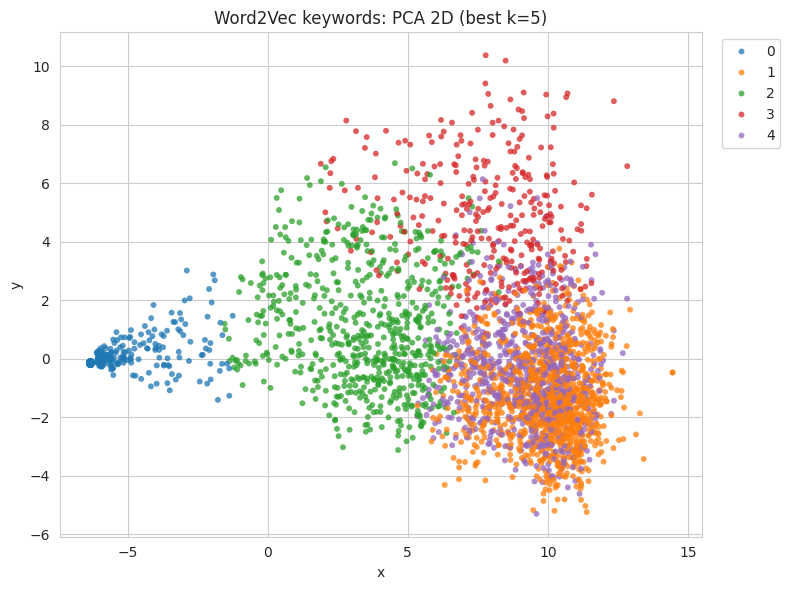

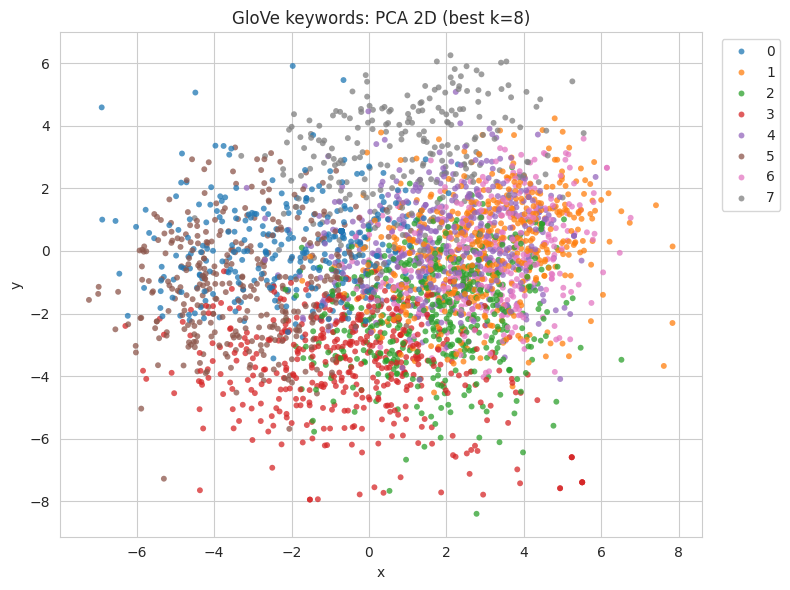

In [ ]:
# 2D визуализация Word2Vec/GloVe (best k)
if Xs_w2v is not None and labels_w2v is not None:
    X2_w2v = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xs_w2v)
    plot_w2v = pd.DataFrame({'x': X2_w2v[:, 0], 'y': X2_w2v[:, 1], 'cluster': labels_w2v})

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=plot_w2v.sample(min(len(plot_w2v), 7000), random_state=RANDOM_STATE),
        x='x', y='y', hue='cluster', palette='tab10', s=18, alpha=0.75, linewidth=0
    )
    plt.title(f'Word2Vec keywords: PCA 2D (best k={best_k_w2v})')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

if Xs_glove is not None and labels_glove is not None:
    X2_glove = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xs_glove)
    plot_glove = pd.DataFrame({'x': X2_glove[:, 0], 'y': X2_glove[:, 1], 'cluster': labels_glove})

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=plot_glove.sample(min(len(plot_glove), 7000), random_state=RANDOM_STATE),
        x='x', y='y', hue='cluster', palette='tab10', s=18, alpha=0.75, linewidth=0
    )
    plt.title(f'GloVe keywords: PCA 2D (best k={best_k_glove})')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
# Сохраняем baseline-результаты
OUT_METRICS = PROJECT_DIR / 'semantic_kmeans_metrics.parquet'
OUT_FINAL = PROJECT_DIR / 'semantic_clusters_word_baseline.parquet'

if out_w2v is not None:
    OUT_W2V = PROJECT_DIR / 'semantic_clusters_word2vec_kmeans.parquet'
    out_w2v.to_parquet(OUT_W2V, index=False)
    print('Saved:', OUT_W2V)

if out_glove is not None:
    OUT_GLOVE = PROJECT_DIR / 'semantic_clusters_glove_kmeans.parquet'
    out_glove.to_parquet(OUT_GLOVE, index=False)
    print('Saved:', OUT_GLOVE)

# Объединенный файл с кластерами:
# при раздельных запусках НЕ перезаписываем старые колонки, а дозаписываем новые.
final_df = base_df[[KEYWORD_COL]].copy()
if OUT_FINAL.exists():
    prev_final = pd.read_parquet(OUT_FINAL)
    final_df = final_df.merge(prev_final, on=KEYWORD_COL, how='left')

if out_w2v is not None:
    final_df = final_df.drop(columns=['cluster_word2vec'], errors='ignore')
    final_df['cluster_word2vec'] = out_w2v['cluster_word2vec'].values

if out_glove is not None:
    final_df = final_df.drop(columns=['cluster_glove'], errors='ignore')
    final_df['cluster_glove'] = out_glove['cluster_glove'].values

if len(final_df.columns) > 1:
    final_df.to_parquet(OUT_FINAL, index=False)
    print('Saved:', OUT_FINAL)

# Метрики тоже объединяем с предыдущими результатами, чтобы раздельные прогоны не терялись
if not results_df.empty:
    merged_metrics = results_df.copy()
    if OUT_METRICS.exists():
        prev_metrics = pd.read_parquet(OUT_METRICS)
        merged_metrics = pd.concat([prev_metrics, results_df], ignore_index=True)
        merged_metrics = merged_metrics.drop_duplicates(subset=['embedding', 'k'], keep='last')

    merged_metrics.to_parquet(OUT_METRICS, index=False)
    print('Saved:', OUT_METRICS)

# Сводные describe по каждому методу
if res_w2v is not None and not res_w2v.empty:
    print('\nWord2Vec metrics describe:')
    display(res_w2v[['silhouette', 'calinski_harabasz', 'davies_bouldin', 'intra_cosine', 'rank_sum']].describe())

if res_glove is not None and not res_glove.empty:
    print('\nGloVe metrics describe:')
    display(res_glove[['silhouette', 'calinski_harabasz', 'davies_bouldin', 'intra_cosine', 'rank_sum']].describe())

Saved: /content/drive/MyDrive/Диплом/semantic_clusters_word2vec_kmeans.parquet
Saved: /content/drive/MyDrive/Диплом/semantic_clusters_glove_kmeans.parquet
Saved: /content/drive/MyDrive/Диплом/semantic_clusters_word_baseline.parquet
Saved: /content/drive/MyDrive/Диплом/semantic_kmeans_metrics.parquet

Word2Vec metrics describe:


,silhouette,calinski_harabasz,davies_bouldin,intra_cosine,rank_sum
count,3.000000,3.000000,3.000000,0.0,3.000000
mean,0.523872,6773.420410,3.413417,NaN,6.000000
std,0.044908,2550.291482,0.218228,NaN,1.732051
min,0.472107,4775.901367,3.199245,NaN,4.000000
25%,0.509605,5337.100830,3.302382,NaN,5.500000
50%,0.547103,5898.300293,3.405518,NaN,7.000000
75%,0.549755,7772.179932,3.520503,NaN,7.000000
max,0.552406,9646.059570,3.635487,NaN,7.000000



GloVe metrics describe:


,silhouette,calinski_harabasz,davies_bouldin,intra_cosine,rank_sum
count,3.000000,3.000000,3.000000,0.0,3.0
mean,0.433423,973.928121,3.448153,NaN,6.0
std,0.008954,202.443077,0.087487,NaN,1.0
min,0.423637,788.583435,3.383472,NaN,5.0
25%,0.429532,865.909882,3.398381,NaN,5.5
50%,0.435427,943.236328,3.413290,NaN,6.0
75%,0.438316,1066.600464,3.480494,NaN,6.5
max,0.441205,1189.964600,3.547698,NaN,7.0


In [ ]:
# Stability check: насколько устойчивы метрики к размеру сэмпла
sample_sizes = [30000, 50000, 100000]


def metrics_on_sample(X: np.ndarray, labels: np.ndarray, sample_size: int, seed: int) -> dict[str, float]:
    n = X.shape[0]
    if n == 0:
        return {
            'silhouette': np.nan,
            'calinski_harabasz': np.nan,
            'davies_bouldin': np.nan,
            'n_used': 0,
        }

    if sample_size >= n:
        idx = np.arange(n)
    else:
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=sample_size, replace=False)

    X_eval = X[idx]
    y_eval = labels[idx]

    if len(np.unique(y_eval)) < 2:
        return {
            'silhouette': np.nan,
            'calinski_harabasz': np.nan,
            'davies_bouldin': np.nan,
            'n_used': int(len(idx)),
        }

    return {
        'silhouette': float(silhouette_score(X_eval, y_eval, metric='euclidean')),
        'calinski_harabasz': float(calinski_harabasz_score(X_eval, y_eval)),
        'davies_bouldin': float(davies_bouldin_score(X_eval, y_eval)),
        'n_used': int(len(idx)),
    }


stability_rows = []
models_to_check = [
    ('word2vec', Xs_w2v, labels_w2v, best_k_w2v),
    ('glove', Xs_glove, labels_glove, best_k_glove),
]

for model_name, Xs_model, labels_model, best_k_model in models_to_check:
    if Xs_model is None or labels_model is None:
        continue

    for s in sample_sizes:
        m = metrics_on_sample(Xs_model, labels_model, sample_size=s, seed=RANDOM_STATE)
        stability_rows.append({
            'embedding': model_name,
            'best_k': int(best_k_model) if best_k_model is not None else np.nan,
            'sample_size_requested': int(s),
            'sample_size_used': m['n_used'],
            'silhouette': m['silhouette'],
            'calinski_harabasz': m['calinski_harabasz'],
            'davies_bouldin': m['davies_bouldin'],
        })

if stability_rows:
    stability_df = pd.DataFrame(stability_rows)
    stability_df = stability_df.sort_values(['embedding', 'sample_size_used']).reset_index(drop=True)

    print('Stability check by sample size (for best_k labels):')
    display(stability_df)

    OUT_STABILITY = PROJECT_DIR / 'semantic_kmeans_stability_check.parquet'
    stability_df.to_parquet(OUT_STABILITY, index=False)
    print('Saved:', OUT_STABILITY)
else:
    print('Stability check skipped: no available model outputs (labels/Xs).')

Stability check by sample size (for best_k labels):


,embedding,best_k,sample_size_requested,sample_size_used,silhouette,calinski_harabasz,davies_bouldin
0,glove,8,30000,30000,0.435427,943.236328,3.383472
1,glove,8,50000,50000,0.430835,1545.597656,3.391900
2,glove,8,100000,100000,0.437224,3128.253662,3.389642


Saved: /content/drive/MyDrive/Диплом/semantic_kmeans_stability_check.parquet


In [ ]:
# Интерактивная 3D-визуализация (крутится мышкой) через Plotly
# Если plotly не установлен, раскомментируй строку ниже:
# %pip install -q plotly

import plotly.express as px

PCA_3D_INTERACTIVE_SAMPLE_SIZE = 12000

interactive_models_3d = [
    ('word2vec', Xs_w2v, labels_w2v, best_k_w2v),
    ('glove', Xs_glove, labels_glove, best_k_glove),
]

shown_any = False
for model_name, Xs_model, labels_model, best_k_model in interactive_models_3d:
    if Xs_model is None or labels_model is None:
        continue

    n = len(labels_model)
    plot_n = min(n, PCA_3D_INTERACTIVE_SAMPLE_SIZE)
    rng = np.random.default_rng(RANDOM_STATE)
    plot_idx = rng.choice(n, size=plot_n, replace=False)

    X_plot = np.asarray(Xs_model[plot_idx], dtype=np.float32)
    y_plot = labels_model[plot_idx]

    X3 = PCA(n_components=3, random_state=RANDOM_STATE).fit_transform(X_plot)
    plot_df_3d = pd.DataFrame({
        'PC1': X3[:, 0],
        'PC2': X3[:, 1],
        'PC3': X3[:, 2],
        'cluster': y_plot.astype(str),
    })

    fig = px.scatter_3d(
        plot_df_3d,
        x='PC1', y='PC2', z='PC3',
        color='cluster',
        opacity=0.7,
        title=f'{model_name} keywords: interactive PCA 3D (sample={plot_n}, best k={best_k_model})',
    )
    fig.update_traces(marker=dict(size=2))
    fig.update_layout(legend_title_text='cluster', margin=dict(l=0, r=0, b=0, t=40))
    fig.show()
    shown_any = True

if not shown_any:
    print('Interactive 3D plot skipped: no available model outputs (labels/Xs).')